# Imports

In [12]:
import requests
from pathlib import Path
import os
from math import radians, cos, sin, asin, sqrt
from itertools import permutations
import time
import pandas as pd
from datetime import datetime, timedelta

import geopandas as gpd
import osmium
from shapely.geometry import LineString, Point
import re
import matplotlib.pyplot as plt
import networkx as nx

# Definition of constants, API keys, helper function

In [124]:
BASE_DB_API = "https://apis.deutschebahn.com/db-api-marketplace/apis/"
STOP_PLACES_URL = "https://apis.deutschebahn.com/db-api-marketplace/apis/ris-stations/v1/stop-places"
RIS_STATION_URL = BASE_DB_API + "ris-station/v1/stations/"

V6_TRANSPORT_BASE_URL = "https://v6.db.transport.rest"

ROOT_DIR = Path(os.getcwd())
RAW_DATA_DIR = ROOT_DIR / "Raw_Data"
PROCESSED_DATA_DIR = ROOT_DIR / "Processed_Data"

scraping_raw_output_file = RAW_DATA_DIR / "train_routes_scraped.csv"
scraping_cleaned_output_file = PROCESSED_DATA_DIR / "train_routes_scraped.csv"

DB_CLIENT_ID = "a9f83c55d26c3ee7f48f4ce887ec2a57"
DB_API_KEY = "422cac21a0a83876c75efb8806589ea0"

header_ris = {
    "DB-Client-Id": DB_CLIENT_ID,
    "DB-Api-Key": DB_API_KEY,
    "accept": "application/vnd.de.db.ris+json"
}

SCRAPING_RATE_LIMIT_SLEEP = 1.0  # Seconds to sleep between requests to respect 100 req/min

def haversine(lat1, lon1, lat2, lon2):
    """ Calculate distance in km between two points """
    R = 6371 # Earth radius
    dLat = radians(lat2 - lat1)
    dLon = radians(lon2 - lon1)
    a = sin(dLat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dLon/2)**2
    return 2 * R * asin(sqrt(a))

#  Railway stations selection & filtering

First, match train station with selected cities from simplemaps ( Processed_Data/cities_500K). Later for matched cities retrieve required timetables.

Matching should be done geospatially

In [38]:
cities_data = pd.read_csv(PROCESSED_DATA_DIR / "cities_500K.csv")
cities_data.rename(columns={"name_city":"name", "lat_city":"latitude", "lng_city":"longitude","country":"iso_code"}, inplace=True)
cities_data.head()

,name,latitude,longitude,iso_code,population,is_capital
0,Vienna,48.2083,16.3725,AT,1973403.0,True
1,Brussels,50.8467,4.3525,BE,1235192.0,True
2,Antwerp,51.2178,4.4003,BE,536079.0,False
3,Sofia,42.7000,23.3300,BG,1383435.0,True
4,Prague,50.0875,14.4214,CZ,1357326.0,True


# Define functions to filter cities

In [39]:
def get_stations_api_stop_places(cities, base_url = STOP_PLACES_URL, limit = 3):
    """
    Retrieves station information from the Deutsche Bahn API based on the station name.

    Keyword arguments:
    cities -- DataFrame containing city information
    base_url -- Base URL for the API
    limit -- Maximum number of stations to retrieve per city
    Return: DataFrame of stations for given cities
    """

    retrieved_stations = pd.DataFrame(columns=['city_name', 'eva_id', 'station_name', 'latitude', 'longitude'])

    for _, row in cities.iterrows():
        city_name = row['name']
        response = None
        params = {
            "sortBy": "RELEVANCE",
            "onlyActive": "true",
            "withSynonyms": "true",
            "latitude": row['latitude'],
            "longitude": row['longitude'],
            "limit": limit
        }
        success = False
        retries = 0

        while not success and retries < 3:
            response = requests.get(url=f"{base_url}/by-name/{city_name}", params=params, headers=header_ris)

            if response.status_code == 429:
                print(f"Rate limit reached. Sleeping for 1s...")
                time.sleep(1)
                retries += 1
                continue

            if response.status_code == 200:
                stations = response.json().get('stopPlaces', [])
                print(f"City: {city_name}, Stations Found: {len(stations)}")
                for station in stations:
                    latitude = float(station.get('position').get('latitude'))
                    longitude = float(station.get('position').get('longitude'))

                    if haversine(row['latitude'], row['longitude'], latitude, longitude) > 10:
                        print(f"Skipping station {station.get('names').get('DE').get('nameLong')} due to distance.")
                        continue

                    retrieved_stations = pd.concat([retrieved_stations, pd.DataFrame({
                        'city_name': [city_name],
                        'eva_id': [str(station.get('evaNumber'))],
                        'station_name': [str(station.get('names').get('DE').get('nameLong'))],
                        'latitude': [float(station.get('position').get('latitude'))],
                        'longitude': [float(station.get('position').get('longitude'))]
                    })])
                success = True
            else:
                print(f"Error retrieving stations for city {city_name}: {response.status_code}")
                break

            time.sleep(0.09)  # To respect API rate limits

    return retrieved_stations

# Get first station for every city

In [40]:
cities_stations = get_stations_api_stop_places(cities_data, limit=1)

City: Vienna, Stations Found: 1


/var/folders/s8/71y5_hp91nv7z5q2r2dy2tnr0000gn/T/ipykernel_44503/1597653662.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  retrieved_stations = pd.concat([retrieved_stations, pd.DataFrame({


City: Brussels, Stations Found: 1
City: Antwerp, Stations Found: 1
City: Sofia, Stations Found: 1
Skipping station Sofie-Hammer-Straße, Osnabrück due to distance.
City: Prague, Stations Found: 1
City: Berlin, Stations Found: 1
City: Stuttgart, Stations Found: 1
City: Munich, Stations Found: 1
City: Hamburg, Stations Found: 1
City: Cologne, Stations Found: 1
City: Frankfurt, Stations Found: 1
City: Düsseldorf, Stations Found: 1
City: Leipzig, Stations Found: 1
City: Dortmund, Stations Found: 1
City: Essen, Stations Found: 1
City: Bremen, Stations Found: 1
City: Dresden, Stations Found: 1
City: Hannover, Stations Found: 1
City: Nuremberg, Stations Found: 1
City: Duisburg, Stations Found: 1
City: Copenhagen, Stations Found: 1
City: Tallinn, Stations Found: 1
Skipping station Tallinner Straße, Schwerin (Meckl) due to distance.
City: Madrid, Stations Found: 1
Skipping station Madrider Ring, Würzburg due to distance.
City: Barcelona, Stations Found: 1
City: Valencia, Stations Found: 1
Skippi

# Inspect for which cities stations have and have not been found

## No stations found

In [41]:
cities_no_station = pd.merge(cities_data, cities_stations, how='outer',left_on=['name'], right_on=['city_name'], indicator=True).query('_merge == "left_only"')
cities_no_station.reset_index(inplace=True)
cities_no_station

,index,name,latitude_x,longitude_x,iso_code,population,is_capital,city_name,eva_id,station_name,latitude_y,longitude_y,_merge
0,2,Athens,37.9842,23.7281,GR,643452.0,True,NaN,NaN,NaN,NaN,NaN,left_only
1,9,Bucharest,44.4325,26.1039,RO,1716961.0,True,NaN,NaN,NaN,NaN,NaN,left_only
2,20,Gothenburg,57.7075,11.9675,SE,607882.0,False,NaN,NaN,NaN,NaN,NaN,left_only
3,23,Helsinki,60.1708,24.9375,FI,664921.0,True,NaN,NaN,NaN,NaN,NaN,left_only
4,26,Lisbon,38.7253,-9.1500,PT,548703.0,True,NaN,NaN,NaN,NaN,NaN,left_only
5,30,Madrid,40.4169,-3.7033,ES,3266126.0,True,NaN,NaN,NaN,NaN,NaN,left_only
6,34,Málaga,36.7194,-4.4200,ES,586384.0,False,NaN,NaN,NaN,NaN,NaN,left_only
7,35,Naples,40.8333,14.2500,IT,913462.0,False,NaN,NaN,NaN,NaN,NaN,left_only
8,40,Riga,56.9489,24.1064,LV,660187.0,True,NaN,NaN,NaN,NaN,NaN,left_only
9,43,Sevilla,37.3900,-5.9900,ES,684025.0,False,NaN,NaN,NaN,NaN,NaN,left_only


## Stations found

In [42]:
cities_with_stations = pd.merge(cities_data, cities_stations, how='inner',left_on=['name'], right_on=['city_name'])
cities_with_stations

,name,latitude_x,longitude_x,iso_code,population,is_capital,city_name,eva_id,station_name,latitude_y,longitude_y
0,Vienna,48.2083,16.3725,AT,1973403.0,True,Vienna,8103000,Wien Hbf,48.185101,16.377113
1,Brussels,50.8467,4.3525,BE,1235192.0,True,Brussels,8800004,Bruxelles Midi,50.835376,4.335694
2,Antwerp,51.2178,4.4003,BE,536079.0,False,Antwerp,8800007,Antwerpen Centraal,51.215811,4.421168
3,Prague,50.0875,14.4214,CZ,1357326.0,True,Prague,5400014,Praha hl.n.,50.083062,14.436039
4,Berlin,52.5200,13.4050,DE,3755251.0,True,Berlin,8011160,Berlin Hbf,52.525592,13.369545
5,Stuttgart,48.7775,9.1800,DE,632865.0,False,Stuttgart,8000096,Stuttgart Hbf,48.784780,9.182757
6,Munich,48.1375,11.5750,DE,1512491.0,False,Munich,8000261,München Hbf,48.140232,11.558335
7,Hamburg,53.5500,10.0000,DE,1892122.0,False,Hamburg,8002549,Hamburg Hbf,53.552736,10.006909
8,Cologne,50.9364,6.9528,DE,1084831.0,False,Cologne,8003368,Köln Messe/Deutz,50.940874,6.975001
9,Frankfurt,50.1106,8.6822,DE,773068.0,False,Frankfurt,8000105,Frankfurt(Main)Hbf,50.106682,8.662828


# Definition of necessary functions for route scraping

In [ ]:
def get_next_representative_weekday():
    """
    Finds the next Tuesday or Wednesday.
    Mid-week days have the most consistent 'standard' schedules.
    """
    now = datetime.now()
    # 0=Mon, 1=Tue, 2=Wed...
    days_ahead = (1 - now.weekday() + 7) % 7 # Target Tuesday
    if days_ahead == 0: days_ahead = 7 # If today is Tuesday, get next week

    target_date = now + timedelta(days=days_ahead)
    # set to 08:00 AM - Peak morning traffic usually has the best connections
    return target_date.replace(hour=8, minute=0, second=0, microsecond=0)

def fetch_fastest_connection(origin_id, dest_id):
    """
    Makes a SINGLE smart request to find the fastest connection.
    Retrieves 5 options and picks the minimum duration.
    """
    target_date = get_next_representative_weekday()

    params = {
        "from": origin_id,
        "to": dest_id,
        "departure": target_date.isoformat(),
        "results": 5,           # Get 5 options in ONE request
        "national": "true",     # Prefer High Speed
        "nationalExpress": "true",
        "transfers": 4          # Allow complex routes if they are faster
    }

    # Retry logic for stability
    for attempt in range(3):
        try:
            response = requests.get(f"{V6_TRANSPORT_BASE_URL}/journeys", params=params, timeout=10)

            if response.status_code == 200:
                data = response.json()
                journeys = data.get('journeys', [])

                if not journeys:
                    return None

                # Optimization: Process all 5 results locally to find the minimum
                min_duration = float('inf')
                best_journey = None

                for journey in journeys:
                    if not journey.get('legs'): continue

                    dep = datetime.fromisoformat(journey['legs'][0]['departure'])
                    arr = datetime.fromisoformat(journey['legs'][-1]['arrival'])
                    duration = (arr - dep).total_seconds() / 60

                    if duration < min_duration:
                        min_duration = duration
                        best_journey = journey
                        best_journey['calculated_duration'] = int(duration)

                # Extract details from the winner
                legs = best_journey['legs']
                train_names = [l.get('line', {}).get('name', '') for l in legs if l.get('mode') == 'train']

                time.sleep(SCRAPING_RATE_LIMIT_SLEEP) # Respect limits
                return {
                    "origin_id": origin_id,
                    "destination_id": dest_id,
                    "origin_name": legs[0]['origin']['name'],
                    "destination_name": legs[-1]['destination']['name'],
                    "min_duration_minutes": best_journey['calculated_duration'],
                    "transfers": len(legs) - 1,
                    "trains": ", ".join(filter(None, train_names)),
                    "check_date": target_date.strftime("%Y-%m-%d")
                }

            elif response.status_code == 429:
                time.sleep(3 * (attempt + 1)) # Backoff
            elif response.status_code >= 500:
                time.sleep(2)
            else:
                return None

        except Exception as e:
            time.sleep(1)

    return None

def get_efficient_network_data(eva_ids):
    # use permutations because A->B might be slightly different than B->A
    # (e.g. connections matching up)
    pairs = list(permutations(eva_ids, 2))

    results = []

    for i, (origin, dest) in enumerate(pairs):
        print(f"[{i+1}/{len(pairs)}] {origin} -> {dest}...", end=" ", flush=True)

        data = fetch_fastest_connection(origin, dest)

        if data:
            print(f"found: {data['min_duration_minutes']} min")
            results.append(data)
        else:
            print(f"no route found")

    return pd.DataFrame(results)

# Define function to Scrape API with intermittent saves to prevent data loss

In [ ]:
def scrape_train_routes_with_checkpoints(eva_ids, batch_size = 10):
    """
    scrapes train routes and persists to CSV every batch_size API calls.

    Args:
        eva_ids: List of station EVA IDs to query
        batch_size: Save to CSV after this many successful API calls (default: 10)
    """

    processed_pairs = set()
    if scraping_raw_output_file.exists():
        existing_df = pd.read_csv(scraping_raw_output_file)
        processed_pairs = set(zip(existing_df['origin_id'], existing_df['destination_id']))
        print(f"found {len(processed_pairs)} existing routes, resuming scraping..")
    else:
        print(f"no existing routes found, created new output file {scraping_raw_output_file}")

    pairs = list(permutations(eva_ids, 2))
    pending_pairs = [p for p in pairs if p not in processed_pairs]

    batch_results = []
    api_calls_count = 0
    failed_count = 0

    try:
        for idx, (origin, dest) in enumerate(pending_pairs):
            pair_num = idx + len(processed_pairs) + 1
            print(f"[{pair_num}/{len(pairs)}] {origin} → {dest}...", end=" ", flush=True)

            try:
                start_time = time.time()
                data = fetch_fastest_connection(origin, dest)
                elapsed = time.time() - start_time

                if data:
                    print(f"{data['min_duration_minutes']} min (retrieved in {elapsed} seconds)")
                    batch_results.append(data)
                    api_calls_count += 1
                else:
                    print(f"no route found (retrieved in {elapsed} seconds)")

                    # if no route was found, still add it to output dataset.
                    # this is so that the scraping does not try again for this city combination when restarted
                    data = {
                        "origin_id": origin,
                        "destination_id": dest,
                        "origin_name": "",
                        "destination_name": "",
                        "min_duration_minutes": -1,
                        "transfers": 0,
                        "trains": "",
                        "check_date": get_next_representative_weekday().strftime("%Y-%m-%d")
                    }
                    batch_results.append(data)

                    api_calls_count += 1
                    failed_count += 1

                # batch save every N successful calls
                if api_calls_count >= batch_size:
                    batch_df = pd.DataFrame(batch_results)

                    # append to CSV or create if doesn't exist yet
                    if scraping_raw_output_file.exists():
                        batch_df.to_csv(scraping_raw_output_file, mode='a', header=False, index=False)
                    else:
                        batch_df.to_csv(scraping_raw_output_file, mode='w', header=True, index=False)

                    print(f"\nintermittent save: saved {api_calls_count} routes to {scraping_raw_output_file.name}")

                    batch_results = []
                    api_calls_count = 0

            except Exception as e:
                print(f"error: {e}")
                failed_count += 1
                time.sleep(2) # let's chill a bit after error to be safe
                continue

        # final save of remaining results
        if batch_results:
            batch_df = pd.DataFrame(batch_results)
            if scraping_raw_output_file.exists():
                batch_df.to_csv(scraping_raw_output_file, mode='a', header=False, index=False)
            else:
                batch_df.to_csv(scraping_raw_output_file, mode='w', header=True, index=False)
            print(f"\nsaved {len(batch_results)} remaining routes")

        print(f"scraping complete!")

    except KeyboardInterrupt:
        print(f"interrupted by user")
        # save any remaining batch data before exiting
        if batch_results:
            batch_df = pd.DataFrame(batch_results)
            if scraping_raw_output_file.exists():
                batch_df.to_csv(scraping_raw_output_file, mode='a', header=False, index=False)
            else:
                batch_df.to_csv(scraping_raw_output_file, mode='w', header=True, index=False)
            print(f"saved {len(batch_results)} routes before exit")
        raise

# Run scraping with intermittent saves

Note: as this notebook was refactored as not to include unnecessary code, the full output is not included here.
Overall scraping took approximately 3 hours.

In [ ]:
scrape_train_routes_with_checkpoints(cities_stations['eva_id'].tolist(), batch_size=10)

# Remove duplicates from saved data

In [ ]:
df = pd.read_csv(scraping_raw_output_file)

df = df.drop_duplicates()

df.to_csv(scraping_cleaned_output_file, index=False)

# Add back cities to routes data

Match up train stations with city names again, for easier data matching down the line

In [82]:
df_routes = pd.read_csv(scraping_cleaned_output_file)

df_routes.rename(columns={"origin_name": "origin_station_name", "destination_name": "destination_station_name"}, inplace=True)

cities_stations_names_only = cities_stations[["city_name", "station_name"]]

cities_stations_origin = cities_stations.add_prefix("origin_")
cities_stations_destination = cities_stations.add_prefix("destination_")

df_routes_with_city_names = df_routes.merge(cities_stations_origin, on="origin_station_name")
df_routes_with_city_names = df_routes_with_city_names.merge(cities_stations_destination, on="destination_station_name")

df_routes_with_city_names

,origin_id,destination_id,origin_station_name,destination_station_name,min_duration_minutes,transfers,trains,check_date,origin_city_name_x,origin_eva_id_x,...,route_length,uses_hsr,origin_city_name_y,origin_eva_id_y,origin_latitude_y,origin_longitude_y,destination_city_name_y,destination_eva_id_y,destination_latitude_y,destination_longitude_y
0,8103000,8000261,Wien Hbf,München Hbf,253,2,NaN,2026-01-06,Vienna,8103000,...,4.224530e+05,False,Vienna,8103000,48.185101,16.377113,Munich,8000261,48.140232,11.558335
1,8103000,8002549,Wien Hbf,Hamburg Hbf,524,2,NaN,2026-01-06,Vienna,8103000,...,9.646314e+05,False,Vienna,8103000,48.185101,16.377113,Hamburg,8002549,53.552736,10.006909
2,8103000,8000105,Wien Hbf,Frankfurt(Main)Hbf,384,0,NaN,2026-01-06,Vienna,8103000,...,7.365172e+05,False,Vienna,8103000,48.185101,16.377113,Frankfurt,8000105,50.106682,8.662828
3,8103000,8000085,Wien Hbf,Düsseldorf Hbf,499,2,NaN,2026-01-06,Vienna,8103000,...,9.458476e+05,False,Vienna,8103000,48.185101,16.377113,Düsseldorf,8000085,51.219962,6.794319
4,8103000,8010205,Wien Hbf,Leipzig Hbf,378,4,NaN,2026-01-06,Vienna,8103000,...,6.227263e+05,False,Vienna,8103000,48.185101,16.377113,Leipzig,8010205,51.345471,12.382064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1641,5600207,5100028,Bratislava hl.st.,Krakow Glowny,350,2,NaN,2026-01-06,Bratislava,5600207,...,3.967676e+05,False,Bratislava,5600207,48.158910,17.106466,Kraków,5100028,50.067194,19.947426
1642,5600207,5100069,Bratislava hl.st.,Wroclaw Glowny,380,4,NaN,2026-01-06,Bratislava,5600207,...,4.154733e+05,False,Bratislava,5600207,48.158910,17.106466,Wrocław,5100069,51.098078,17.037088
1643,5600207,5100081,Bratislava hl.st.,Poznan Glowny,407,2,NaN,2026-01-06,Bratislava,5600207,...,5.800692e+05,False,Bratislava,5600207,48.158910,17.106466,Poznań,5100081,52.401993,16.910870
1644,5600207,7400002,Bratislava hl.st.,Stockholm Central,1386,6,NaN,2026-01-06,Bratislava,5600207,...,2.101206e+06,False,Bratislava,5600207,48.158910,17.106466,Stockholm,7400002,59.330014,18.057630


# Add a column indicating the percent of high-speed rail (HSR) utilized by a route

## Load OpenStreetMap data


In [4]:
osm_path = Path('Raw_Data/OSM_Data')
output_dir = Path('Raw_Data/Parquet_Data')
merged_path = Path('Raw_Data/EU_railways.parquet')

osm_path.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

###### (not necessary to run cell below since zip file already contains processed OpenStreetMap data)

In [ ]:
class RailwayExtractor(osmium.SimpleHandler):
    def __init__(self):
        super().__init__()
        self.features = []

    def way(self, w):
        if w.tags.get("railway") != "rail":
            return

        coords = [(n.lon, n.lat) for n in w.nodes if n.location.valid()]
        if len(coords) < 2:
            return

        self.features.append({
            "geometry": LineString(coords),
            "maxspeed": w.tags.get("maxspeed"),
            "service": w.tags.get("service"),
            "usage": w.tags.get("usage"),
            "name": w.tags.get("name"),
        })

def extract_railways(pbf_path):
    handler = RailwayExtractor()
    handler.apply_file(pbf_path, locations=True)

    gdf = gpd.GeoDataFrame(
        handler.features,
        geometry="geometry",
        crs="EPSG:4326"
    )

    return gdf

def parse_maxspeed(val):
    if val is None:
        return None

    s = str(val).lower()

    m = re.search(r"\d+", str(val))
    if not m:
        return None

    speed = float(m.group())
    # Convert mph → km/h
    if "mph" in s:
        speed *= 1.609344
    return speed

def mark_highspeed(gdf):
    gdf = gdf.copy()

    gdf["maxspeed_num"] = gdf["maxspeed"].apply(parse_maxspeed)

    gdf["is_highspeed"] = (
        (gdf["maxspeed_num"] >= 200)
    )

    return gdf

for pbf in osm_path.glob("*.osm.pbf"):
    print(f"Processing {pbf.name}")

    gdf = extract_railways(pbf)
    gdf = mark_highspeed(gdf)

    out = output_dir / f"{pbf.stem}_rail.parquet"
    gdf.to_parquet(out)

## Merge all parquet files into one
###### (not necessary to run cell below since zip file already contains merged parquet file)

In [ ]:
files = output_dir.glob("*.parquet")

gdfs = [gpd.read_parquet(f) for f in files]

merged = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)

merged.to_parquet(merged_path)

## Inspect merged railway data

In [104]:
railways = gpd.read_parquet(merged_path)
print(railways.head) # note large number of rail segments
print(railways[railways['is_highspeed']].head)  # filter for is_highspeed

<bound method NDFrame.head of                                                  geometry maxspeed service  \
0       LINESTRING (-6.24157 53.34133, -6.2423 53.3416...       30    None   
1       LINESTRING (-8.65163 52.34925, -8.64136 52.359...   90 mph    None   
2       LINESTRING (-9.49296 52.05867, -9.49438 52.058...   15 mph    None   
3       LINESTRING (-7.8216 52.67822, -7.821 52.68128,...      160    None   
4       LINESTRING (-7.8235 52.78557, -7.82302 52.7867...      160    None   
...                                                   ...      ...     ...   
931127    LINESTRING (23.35432 54.328, 23.35571 54.32808)      100    None   
931128  LINESTRING (23.35571 54.32808, 23.35686 54.32814)      100    None   
931129     LINESTRING (23.38484 55.9119, 23.386 55.91151)     None    yard   
931130  LINESTRING (23.38685 55.91078, 23.38719 55.910...     None    yard   
931131  LINESTRING (21.23051 55.8913, 21.23041 55.8906...      100  siding   

       usage              name  m

## Review distribution of data

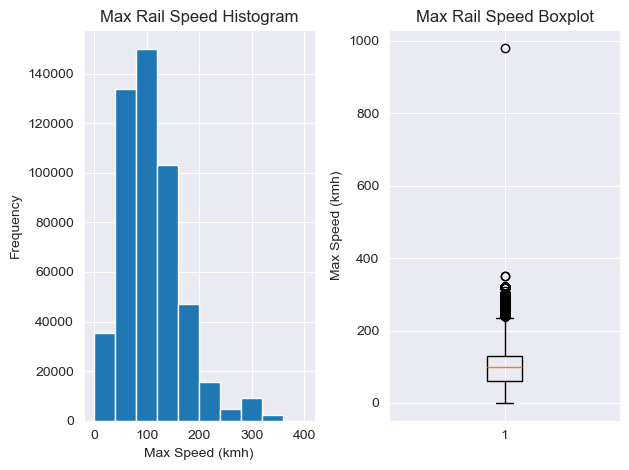

In [93]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist(railways['maxspeed_num'], range=(0, 400))
ax1.set_title('Max Rail Speed Histogram')
ax1.set_xlabel('Max Speed (kmh)')
ax1.set_ylabel('Frequency')

ax2.boxplot(railways['maxspeed_num'].dropna())
ax2.set_title('Max Rail Speed Boxplot')
ax2.set_ylabel('Max Speed (kmh)')

fig.tight_layout()

## Inspect single high outlier

In [94]:
railways.loc[railways['maxspeed_num'] > 300]

,geometry,maxspeed,service,usage,name,maxspeed_num,is_highspeed
232655,"LINESTRING (15.02986 50.08914, 15.0301 50.0890...",980,None,branch,None,980.0,True
614887,"LINESTRING (6.235 48.95857, 6.23524 48.95859, ...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
614932,"LINESTRING (5.64639 48.95345, 5.64745 48.95354)",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
614933,"LINESTRING (5.64745 48.95354, 5.64827 48.95362...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
615962,"LINESTRING (3.25744 49.04457, 3.2597 49.0446)",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
...,...,...,...,...,...,...,...
745712,"LINESTRING (-0.3306 47.91295, -0.33176 47.91316)",320,None,main,Ligne de Connerré à Rennes (LGV),320.0,True
746250,"LINESTRING (2.82456 48.99336, 2.82519 48.99346...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
746251,"LINESTRING (2.82454 48.9934, 2.82516 48.9935, ...",320,None,main,Ligne de Paris à Strasbourg (LGV),320.0,True
886064,"LINESTRING (-3.11107 40.59886, -3.1101 40.5998...",310,None,main,Línea de alta velocidad Madrid-Zaragoza-Barcel...,310.0,True


##### There is no rail line in Europe with a max speed of 980 kmh. The outlier is listed as a branch, meaning that it's supposed to be a railway with less traffic and lower speed than main lines. The coordinates show that this rail segment is directly next to a train station called Pečky, which is east of Prague. The most likely possibility is that this is a data tagging error and the actual max speed should be 98.0 kmh.

##### Correct the outlier speed and verify change. Dropping the outlier is not an option since it could break a route.

##### All other high-speed rail segments have correct max speeds.

In [105]:
try:
    outlier_idx = railways.index[railways['maxspeed_num'] == 980][0]
    railways.at[outlier_idx, 'maxspeed'] = 98.0
    railways.at[outlier_idx, 'maxspeed_num'] = 98.0
    railways.at[outlier_idx, 'is_highspeed'] = False
    print(railways.iloc[outlier_idx]) # inspect corrected record
except IndexError:
    print("The outlier has already been removed")

geometry        LINESTRING (15.029855 50.0891394, 15.0300975 5...
maxspeed                                                     98.0
service                                                      None
usage                                                      branch
name                                                         None
maxspeed_num                                                 98.0
is_highspeed                                                False
Name: 232655, dtype: object


## Inspect records with 0 kmh speeds


In [96]:
railways.loc[railways['maxspeed_num'] == 0]

,geometry,maxspeed,service,usage,name,maxspeed_num,is_highspeed
127444,"LINESTRING (13.95698 45.67992, 13.95669 45.67945)",0,yard,None,None,0.0,False
472746,"LINESTRING (12.31566 51.61648, 12.31569 51.616...",0,yard,None,None,0.0,False
472802,"LINESTRING (12.31729 51.62574, 12.31742 51.62636)",0,yard,None,None,0.0,False
479725,"LINESTRING (12.31876 51.63123, 12.3188 51.6313...",0,yard,None,None,0.0,False
479727,"LINESTRING (12.3176 51.62548, 12.31755 51.6252...",0,yard,None,None,0.0,False
484760,"LINESTRING (13.60041 52.45793, 13.60029 52.457...",0,yard,None,None,0.0,False
513990,"LINESTRING (12.31931 51.63308, 12.31938 51.633...",0,yard,None,None,0.0,False
528417,"LINESTRING (12.20686 51.12934, 12.20659 51.12952)",0,yard,None,None,0.0,False
528418,"LINESTRING (12.20731 51.12916, 12.20727 51.12924)",0,yard,None,None,0.0,False
528419,"LINESTRING (12.20718 51.12929, 12.20723 51.12944)",0,yard,None,None,0.0,False


##### Considering 'usage' being None and the values for 'service', a speed of 0 makes sense for the above records. However, replace with a speed of 0.01 to avoid division by zero errors downstream.

In [106]:
replace_dict = {0: 0.01}
railways['maxspeed_num'] = railways['maxspeed_num'].replace(replace_dict)
railways.loc[railways['maxspeed_num'] == 0] # verify change

,geometry,maxspeed,service,usage,name,maxspeed_num,is_highspeed


## Inspect records with na speeds

In [98]:
railways.loc[railways['maxspeed_num'].isna()]

,geometry,maxspeed,service,usage,name,maxspeed_num,is_highspeed
62,"LINESTRING (-5.93989 54.59477, -5.94003 54.594...",None,None,main,None,NaN,False
63,"LINESTRING (-5.91703 54.59839, -5.91693 54.598...",None,None,main,None,NaN,False
78,"LINESTRING (-5.91711 54.59817, -5.91703 54.59839)",None,None,main,Belfast Central Railway,NaN,False
79,"LINESTRING (-5.93683 54.58799, -5.93671 54.587...",None,None,main,Lisburn Road Tunnel,NaN,False
80,"LINESTRING (-5.9212 54.59059, -5.92146 54.5903...",None,None,main,Belfast Central Railway,NaN,False
...,...,...,...,...,...,...,...
931124,"LINESTRING (23.3543 54.32812, 23.35104 54.3279...",None,siding,None,None,NaN,False
931125,"LINESTRING (23.35684 54.32826, 23.3543 54.32812)",None,siding,None,None,NaN,False
931126,"LINESTRING (23.35431 54.32807, 23.3557 54.32814)",None,siding,None,None,NaN,False
931129,"LINESTRING (23.38484 55.9119, 23.386 55.91151)",None,yard,None,None,NaN,False


##### There are too many rail segments with no speeds. Setting the speed of all these segments to 0.01 kmh could break many routes. Visual inspection of a handful of these rail segments on [OpenRailwayMap](https://www.openrailwaymap.org/) shows that they are generally connected to low-speed lines. So, impute using the 25th percentile of the max speed (60 kmh).

In [108]:
railways['maxspeed_num'] = railways['maxspeed_num'].fillna(railways['maxspeed_num'].quantile(q=0.25))
print(railways.loc[railways['maxspeed_num'].isna()]) # verify change
print(railways.describe())

Empty GeoDataFrame
Columns: [geometry, maxspeed, service, usage, name, maxspeed_num, is_highspeed]
Index: []
        maxspeed_num
count  931132.000000
mean       82.483607
std        46.113093
min         0.010000
25%        60.000000
50%        60.000000
75%       100.000000
max       350.000000


## Build a rail network graph

In [109]:
G = nx.Graph()

# convert to CRS 3035 since better for length calculations
rail_edges = railways[["geometry", "is_highspeed", "maxspeed_num"]].copy()
rail_edges = rail_edges.to_crs(3035)

edge_sindex = rail_edges.sindex

for idx, row in rail_edges.iterrows():
    geom = row['geometry']
    if geom.geom_type == "MultiLineString":
        lines = geom.geoms
    else:
        lines = [geom]

    for line in lines:
        coords = list(line.coords)
        for u, v in zip(coords[:-1], coords[1:]):
            length = Point(u).distance(Point(v)) / 1000 # m to km
            travel_time = (length / row.maxspeed_num) * 60 # hrs to min
            G.add_edge(
                u, v,
                length=length,
                is_highspeed=row.is_highspeed,
                travel_time=travel_time
            )

## Snap stations to the graph

In [110]:
def nearest_edge(point):
    res = edge_sindex.nearest(point) # 1st num always 0 (index of point), 2nd num index of rail edge
    idx = int(res[1, 0])
    return rail_edges.iloc[idx]

def project_to_edge(point, edge_geom):
    """Project a point onto a rail edge."""
    return edge_geom.interpolate(edge_geom.project(point))

def insert_station(G, station_point, edge_row):
    edge_geom = edge_row.geometry
    edge_maxspeed = edge_row.maxspeed_num
    hsr = edge_row.is_highspeed

    projected = project_to_edge(station_point, edge_geom)

    coords = list(edge_geom.coords)

    # find segment where projection lies
    for u, v in zip(coords[:-1], coords[1:]):
        seg = LineString([u, v])
        if seg.distance(projected) < 0.01: # tolerance
            # remove original edge
            if G.has_edge(u, v):
                G.remove_edge(u, v)

            # add two new edges
            G.add_edge(
                u, projected.coords[0],
                length=Point(u).distance(projected) / 1000, # m to km
                is_highspeed=hsr,
                travel_time=((Point(u).distance(projected) / 1000) / edge_maxspeed) * 60 # min
            )
            G.add_edge(
                projected.coords[0], v,
                length=Point(v).distance(projected) / 1000, # m to km
                is_highspeed=hsr,
                travel_time=((Point(v).distance(projected) / 1000) / edge_maxspeed) * 60 # min
            )
            break

    # station node connects to projected point
    G.add_node(projected.coords[0])
    return projected.coords[0]

gpd_stations = gpd.GeoDataFrame(
    cities_with_stations,
    geometry=gpd.points_from_xy(
        cities_with_stations.longitude_y, cities_with_stations.latitude_y
    ),
    crs="EPSG:4326"
)

# project to CRS 3035
gpd_stations = gpd_stations.to_crs(3035)

# build lookup dictionary
station_to_node = {}

for _, row in gpd_stations.iterrows():
    pt = row.geometry
    edge = nearest_edge(pt)
    node = insert_station(G, pt, edge)
    station_to_node[row.station_name] = node

## Compute path & high-speed rail percentage per route
#### Approximate runtime: 2-3 hrs

The method used finds the shortest path between the origin and destination based on the travel time of each rail segment, which is calculated as length / max speed. This may be optimistic since the actual trains may not take the fastest route. Fine-grained information on a train's route is needed for accurate calculations, but this information is not available.

Another option is to calculate the shortest path based on distance. However, this was found to be highly pessimistic since nearby high-speed rail routes would be avoided. An example are routes from Vienna to northern Germany. The shortest path is to take the slow rail routes going through the Czech Republic. But the fastest path, and what is actually taken by the train, is to follow the high-speed rail going through Stuttgart or Nürnberg.

In [111]:
def hsr_share_and_length(origin_node, dest_node):
    """ identify the fastest route between the origin and destination
    then calculate the length (meters) and share of hsr"""
    path = nx.shortest_path(G, origin_node, dest_node, weight="travel_time")

    total = 0
    hsr = 0

    for u, v in zip(path[:-1], path[1:]):
        edge = G[u][v]
        total += edge["length"]
        if edge["is_highspeed"]:
            hsr += edge["length"]

    hsr_share = hsr / total if total > 0 else 0
    return hsr_share, total

df_routes_with_city_names[["hsr_share", "route_length"]] = df_routes_with_city_names.apply(
    lambda r: pd.Series(
        hsr_share_and_length(
            station_to_node[r.origin_station_name],
            station_to_node[r.destination_station_name]
        )
    ),
    axis=1
)

In [123]:
num_hsr_routes = len(df_routes_with_city_names[df_routes_with_city_names['hsr_share'] >= 0.5])
print(f'Of the {len(df_routes_with_city_names)} routes, there are {num_hsr_routes} hsr routes.')
df_routes_with_city_names = df_routes_with_city_names.loc[:, ~df_routes_with_city_names.columns.str.endswith('_y')] # fix join issues
df_routes_with_city_names.columns = df_routes_with_city_names.columns.str.replace('_x$', '', regex=True) # fix column naming issues

Of the 1646 routes, there are 579 hsr routes.


In [125]:
df_routes_with_city_names.to_csv(scraping_cleaned_output_file, index=False)